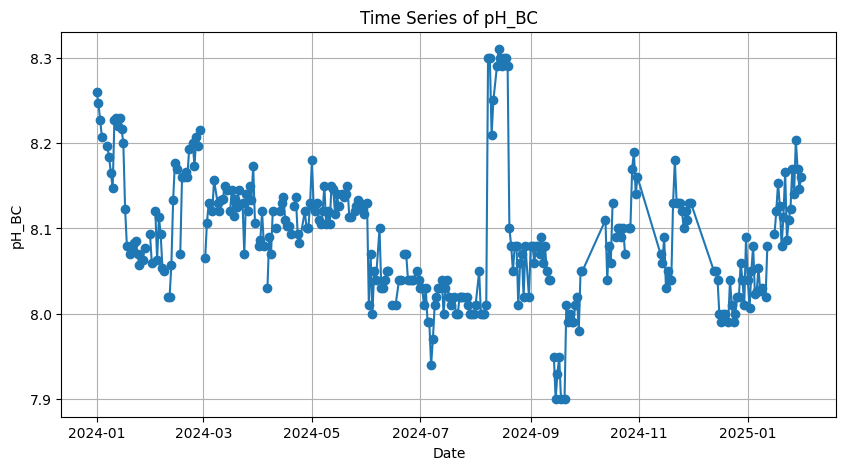

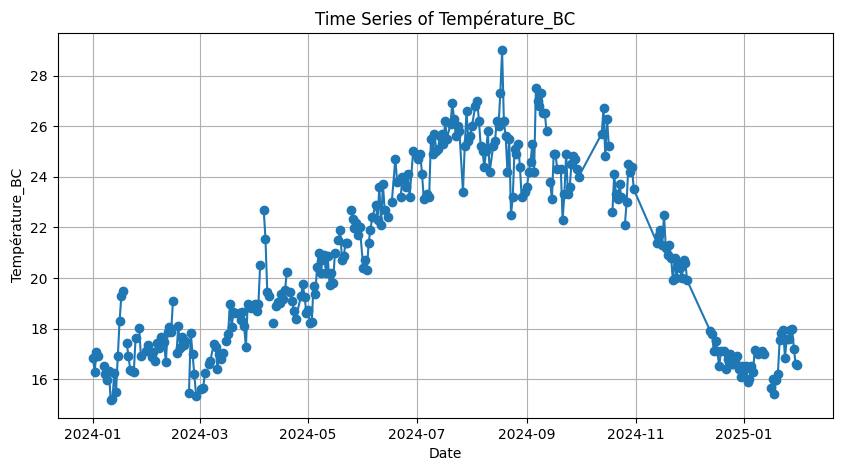

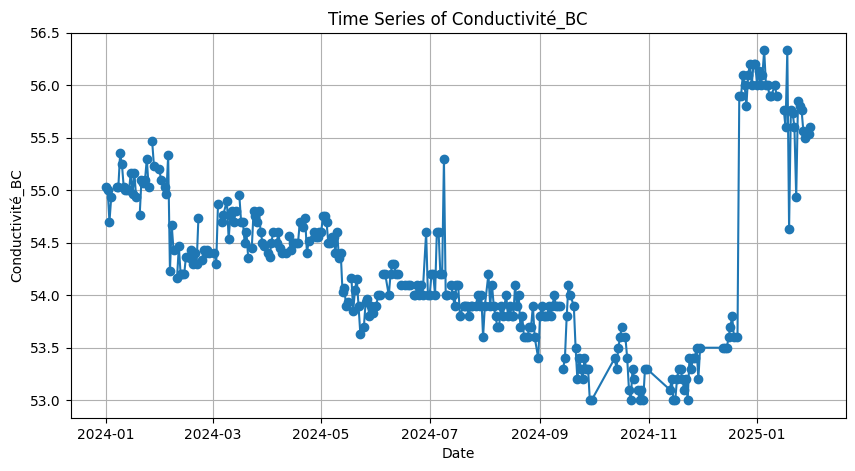

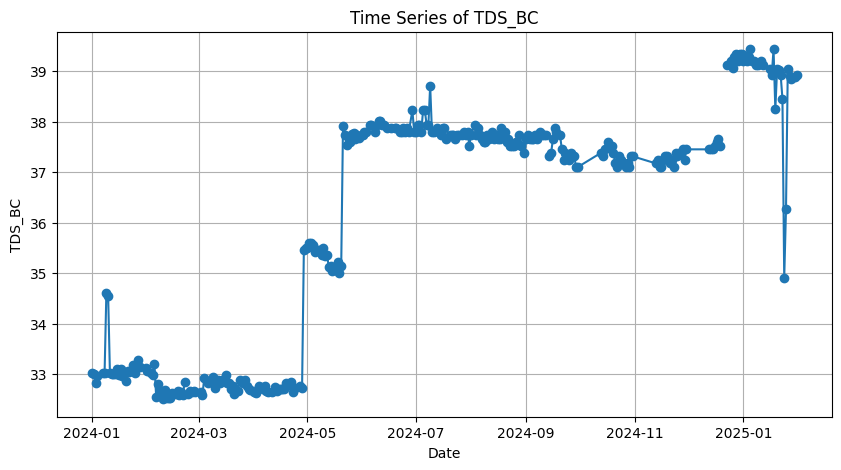

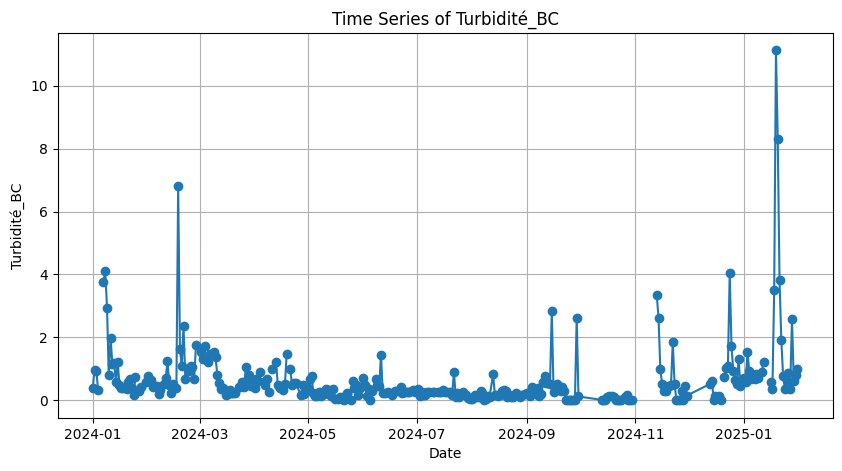

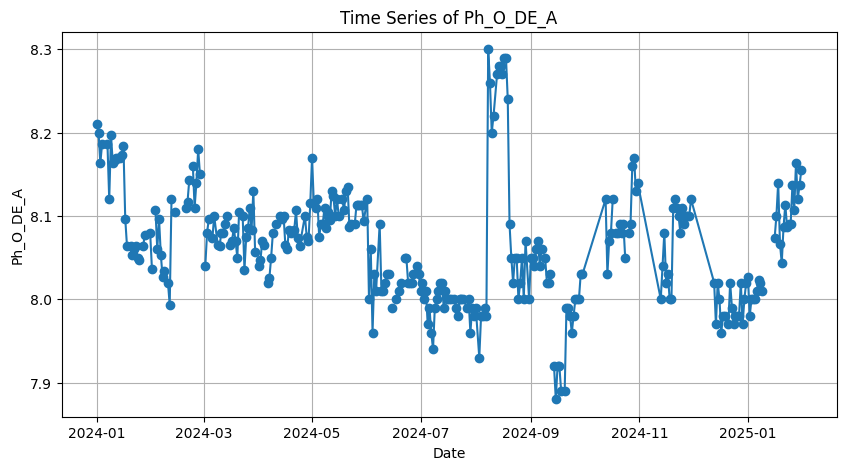

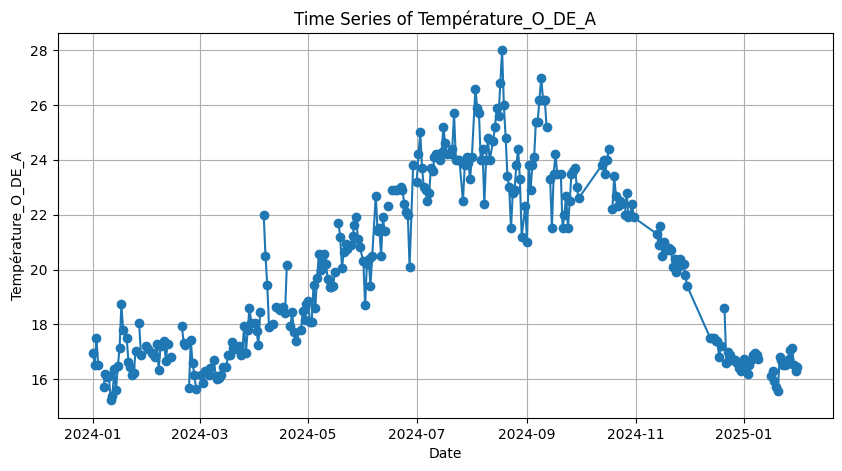

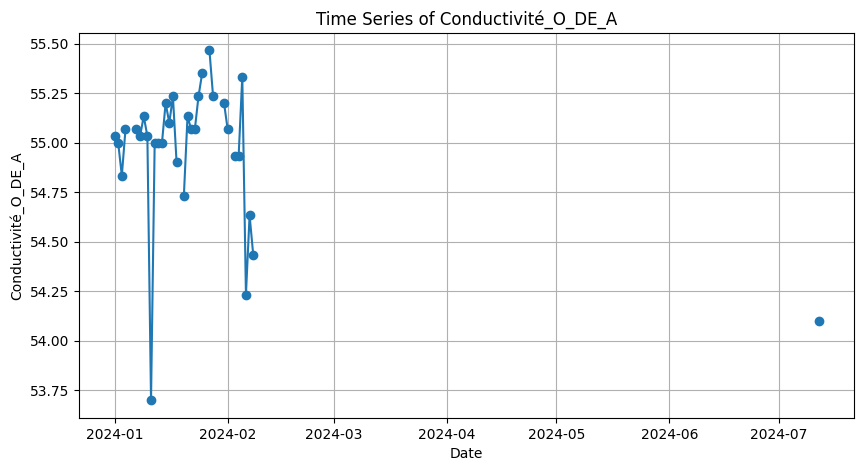

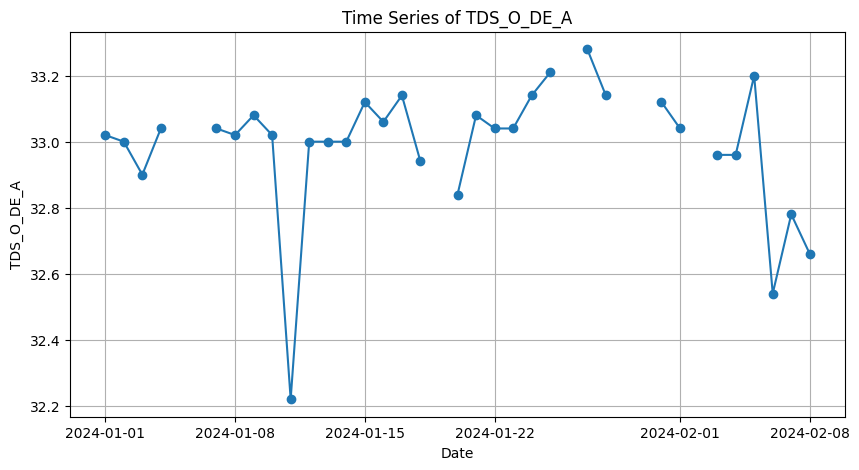

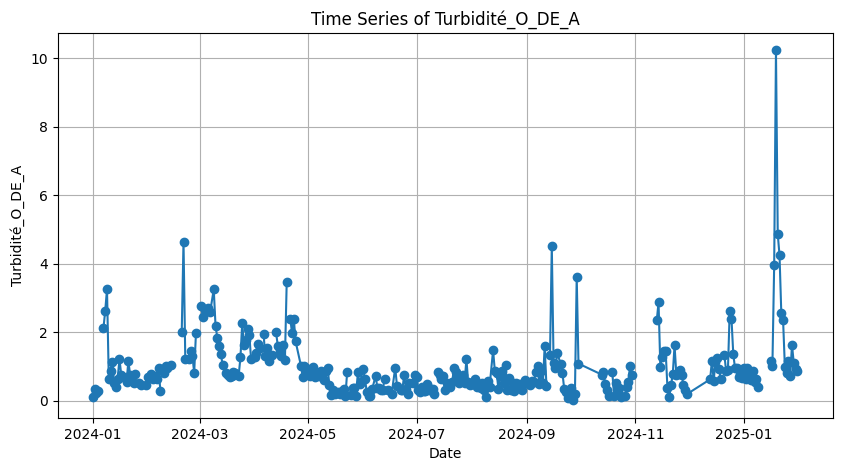

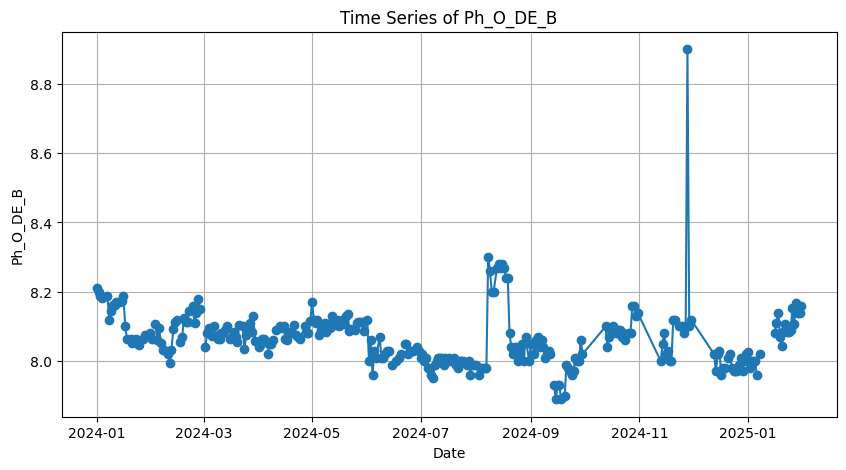

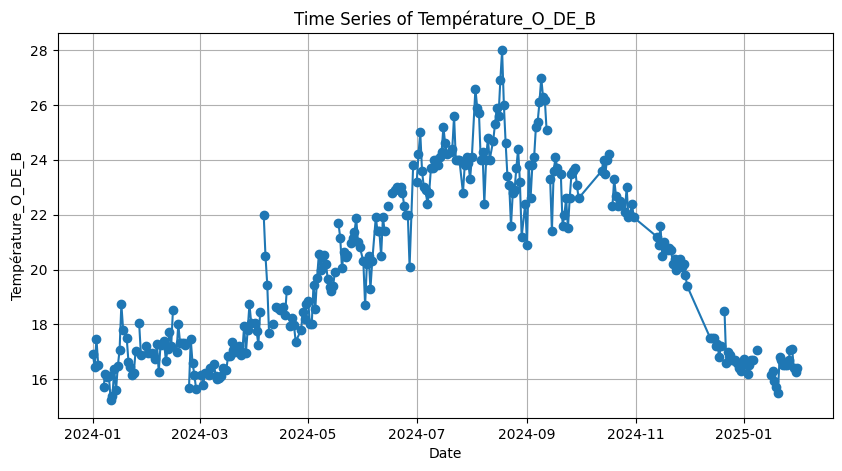

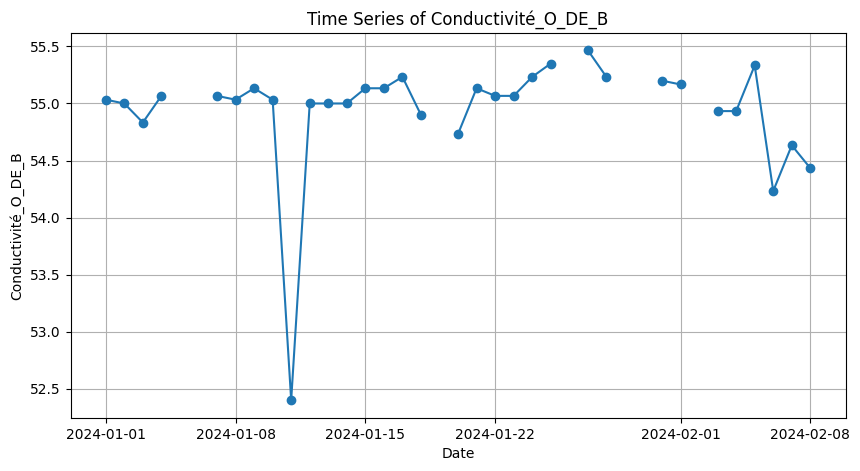

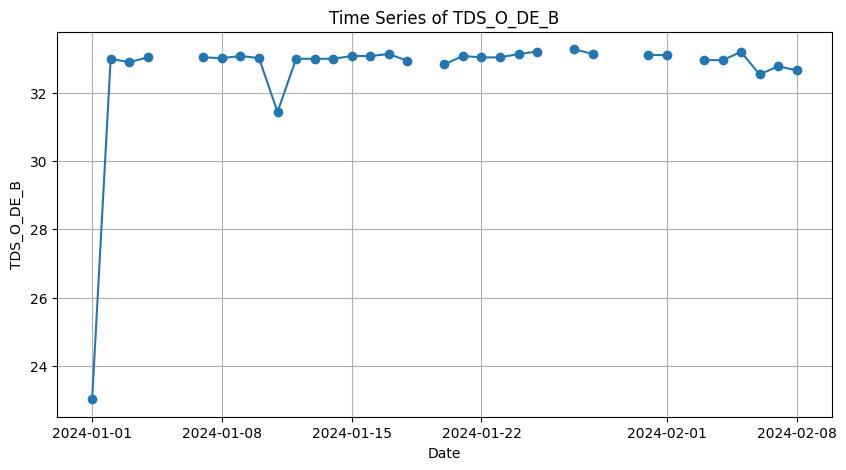

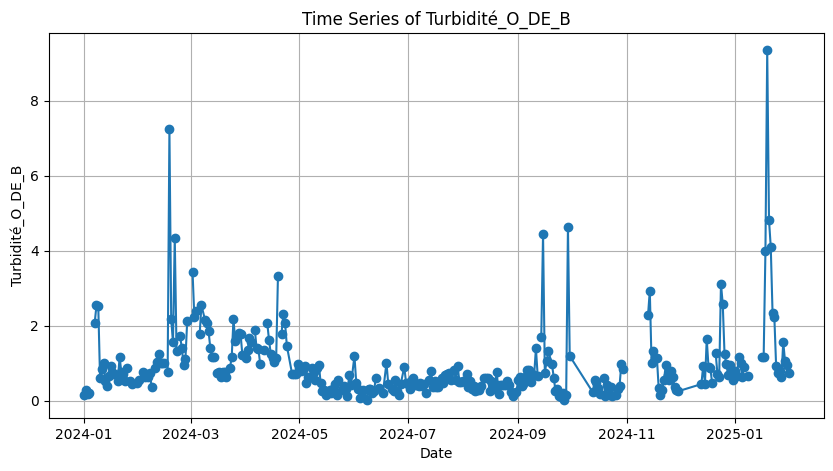

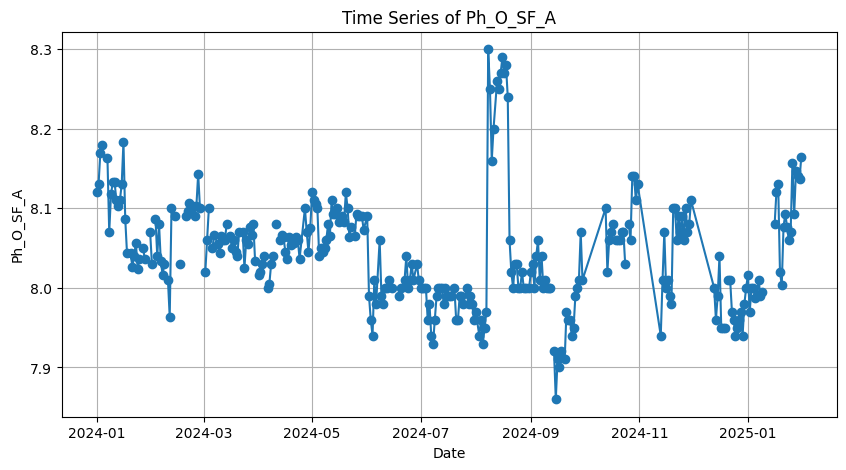

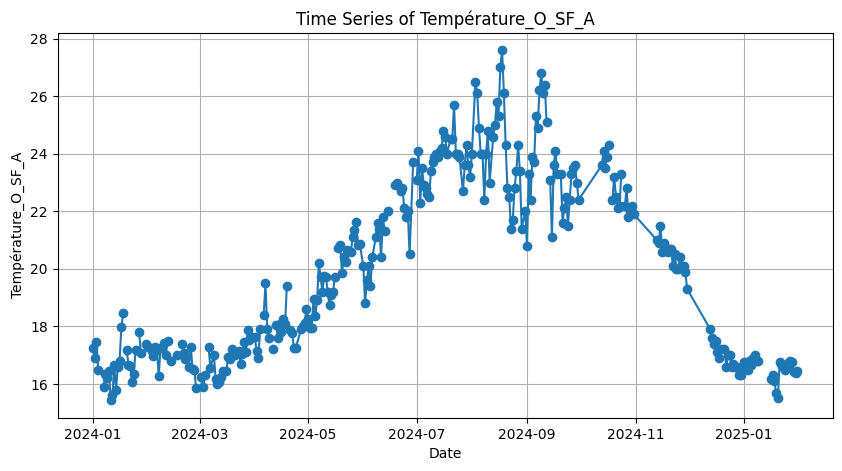

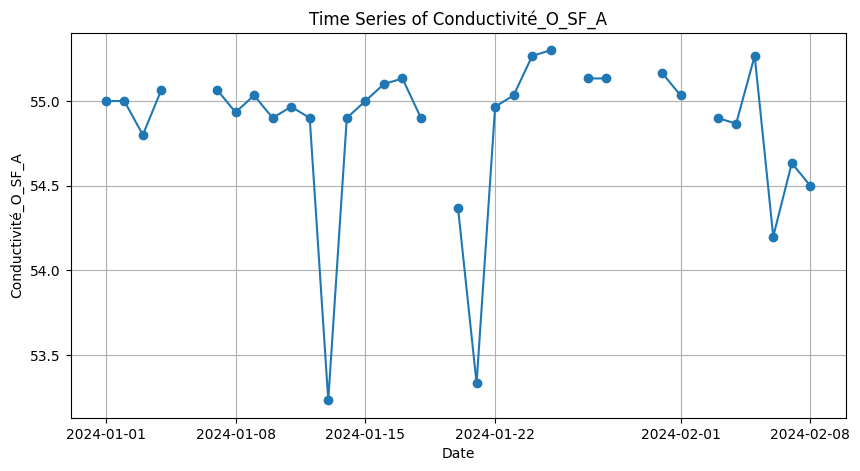

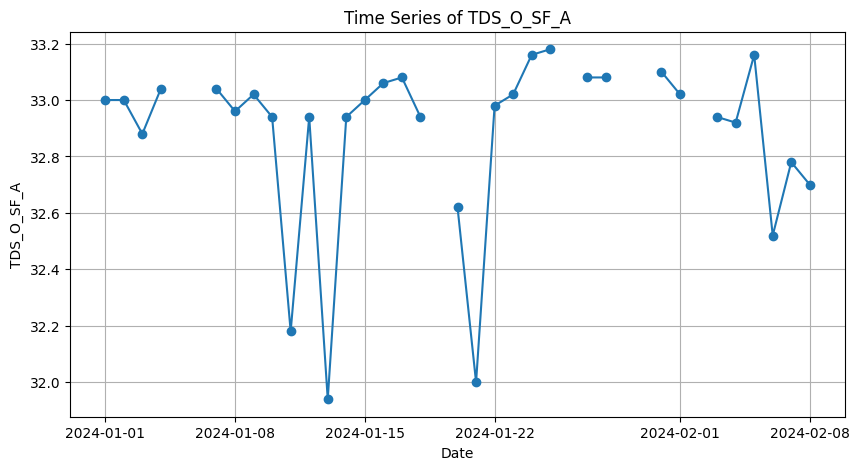

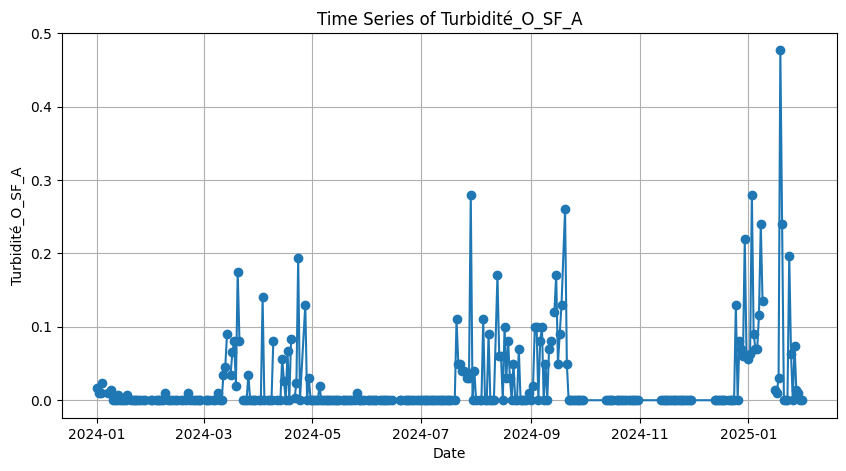

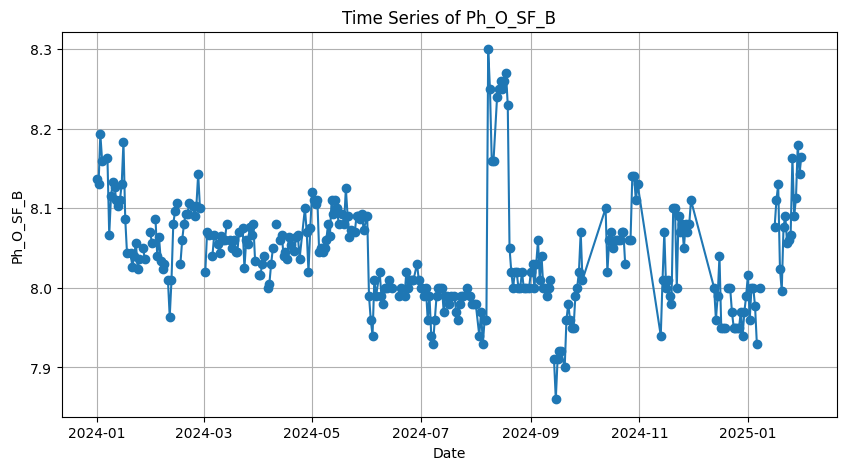

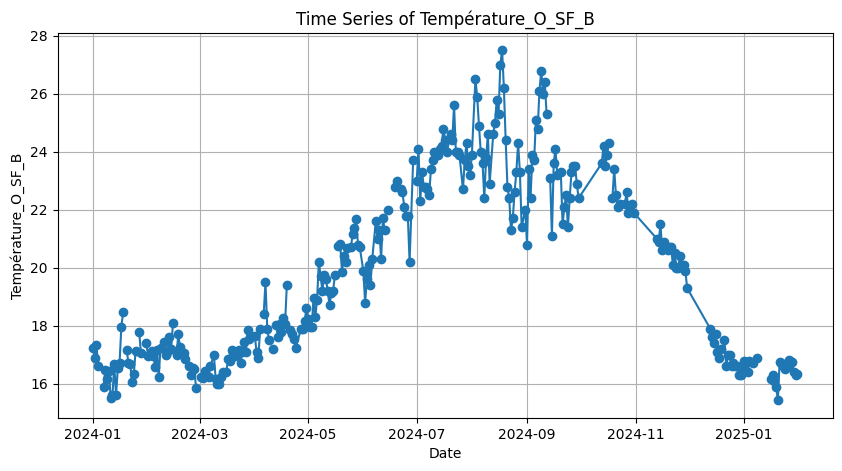

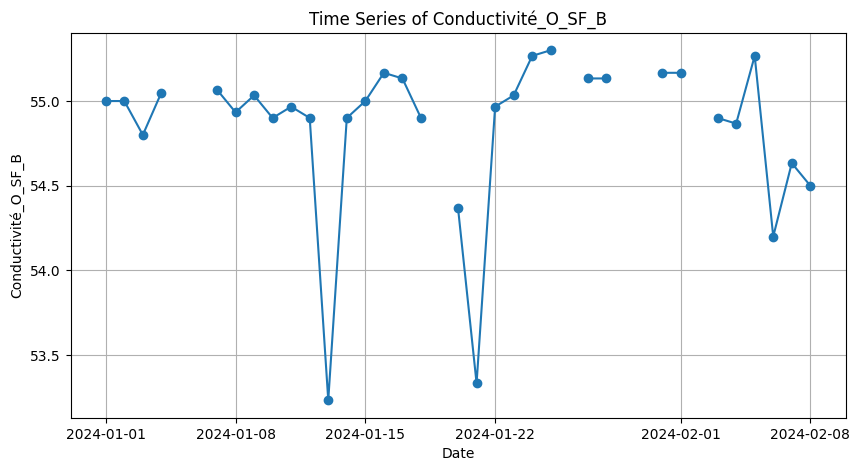

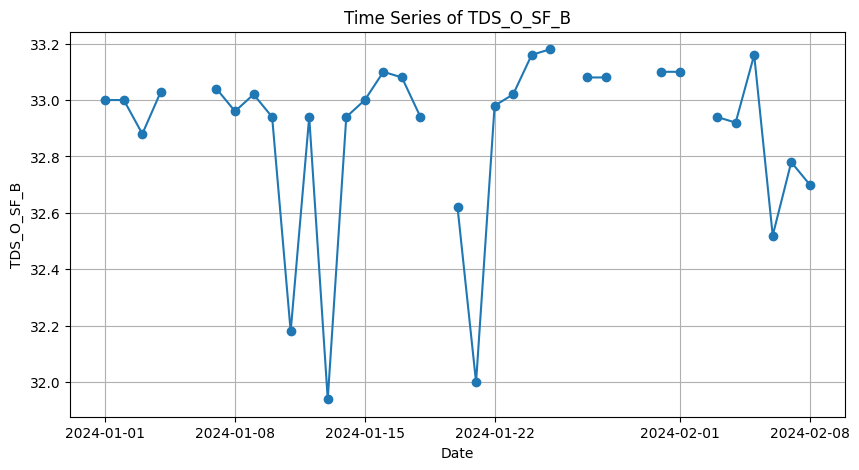

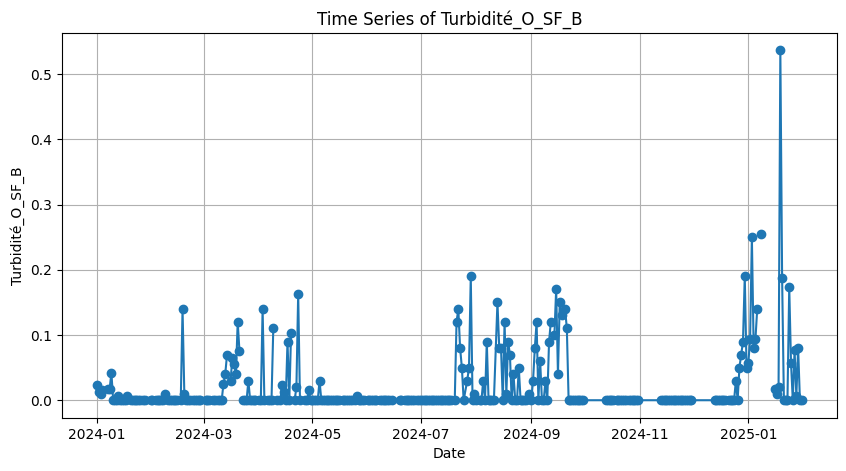

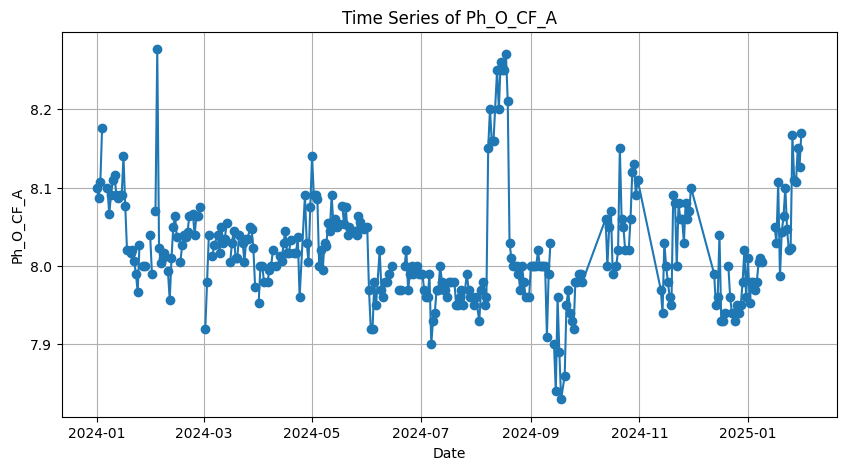

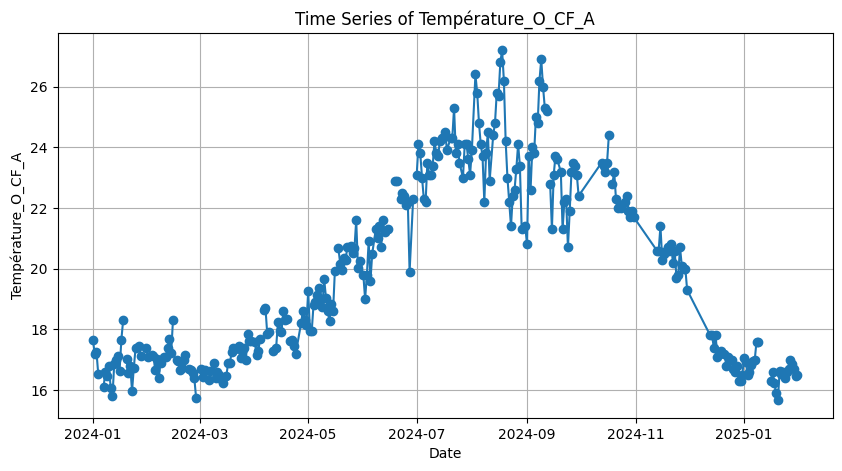

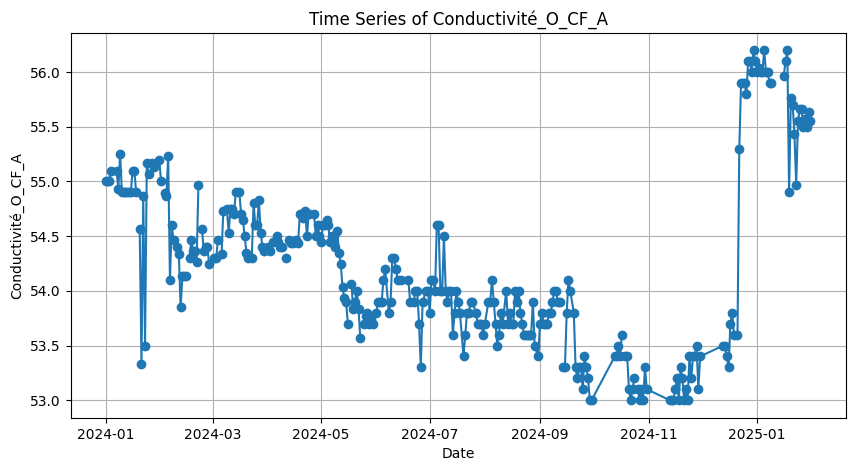

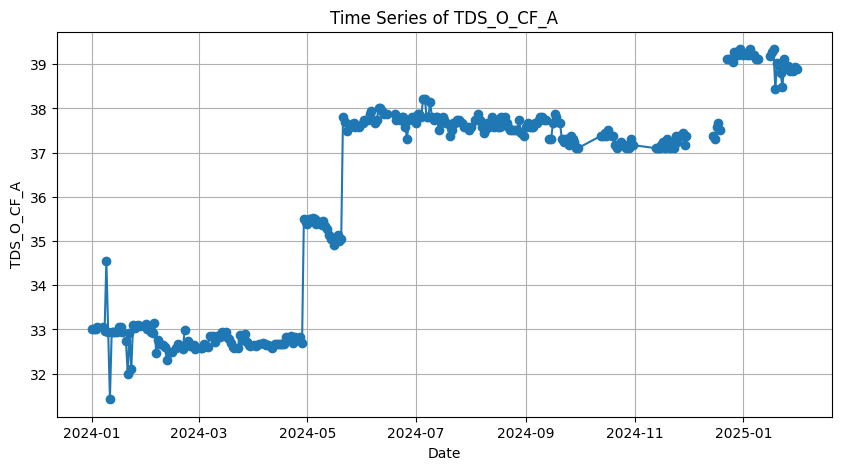

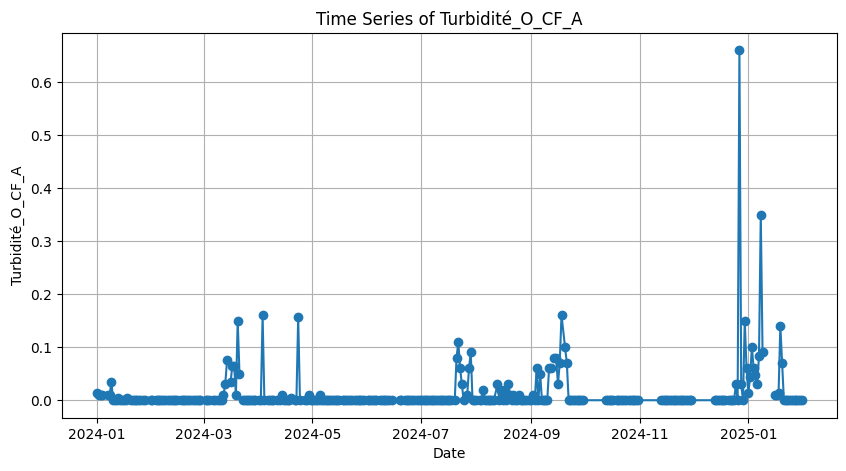

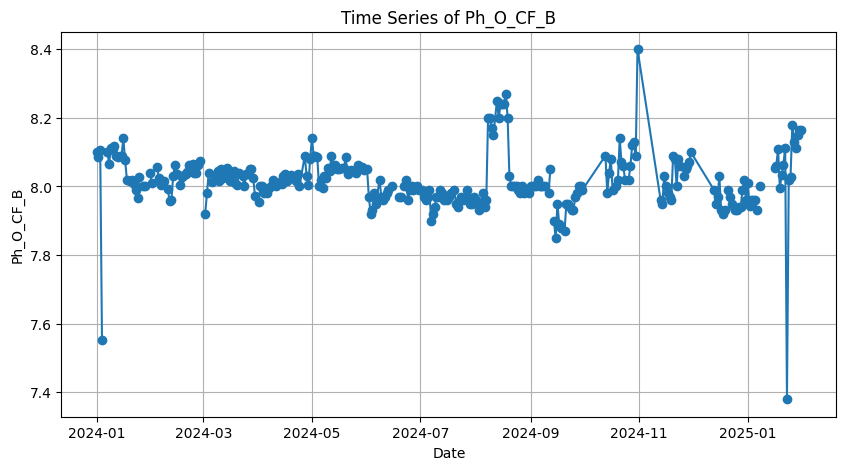

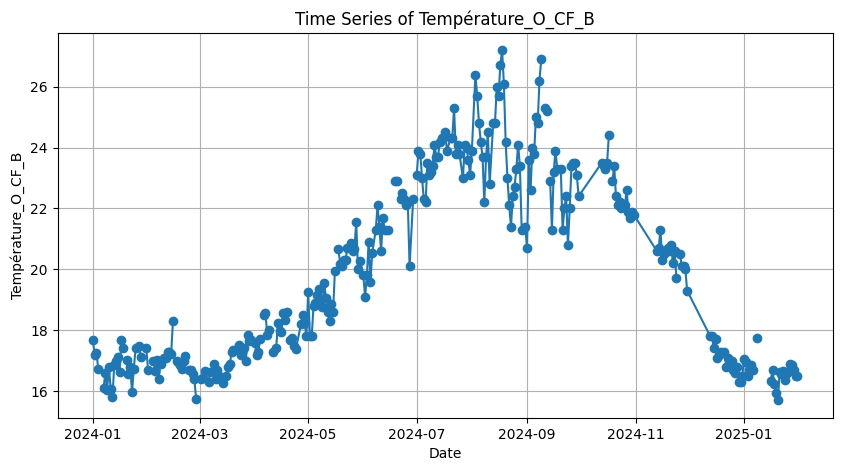

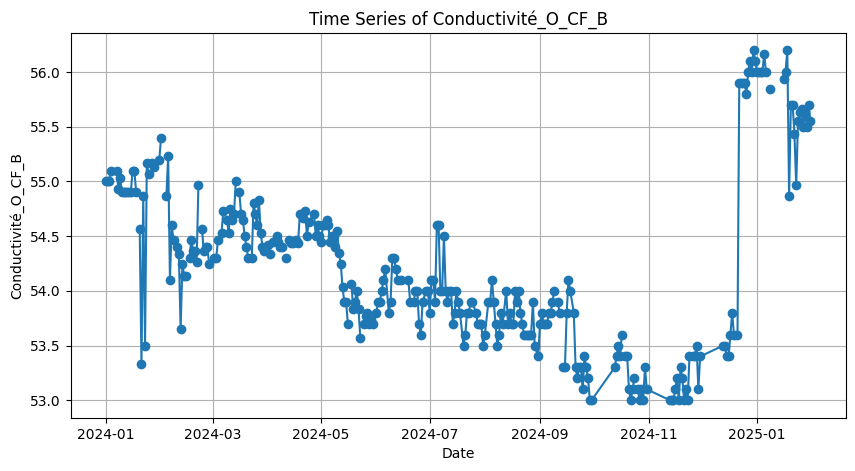

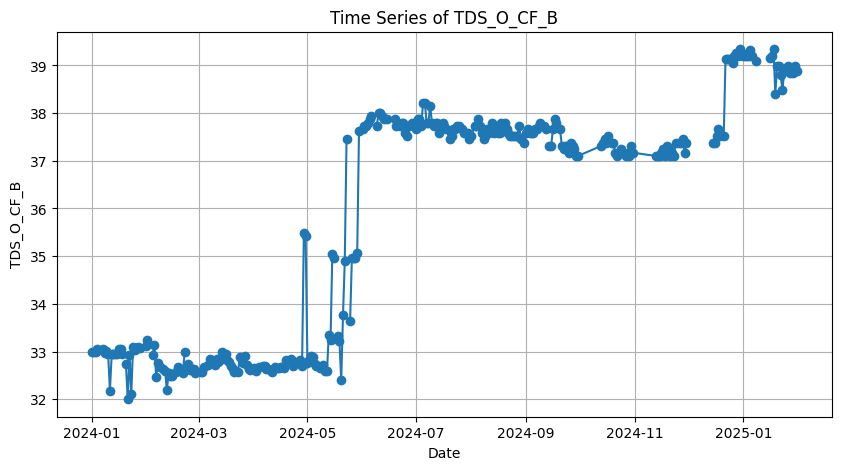

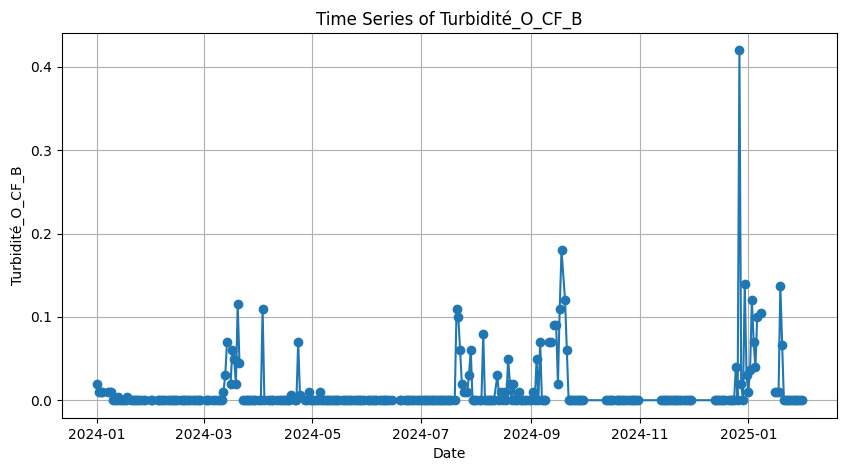

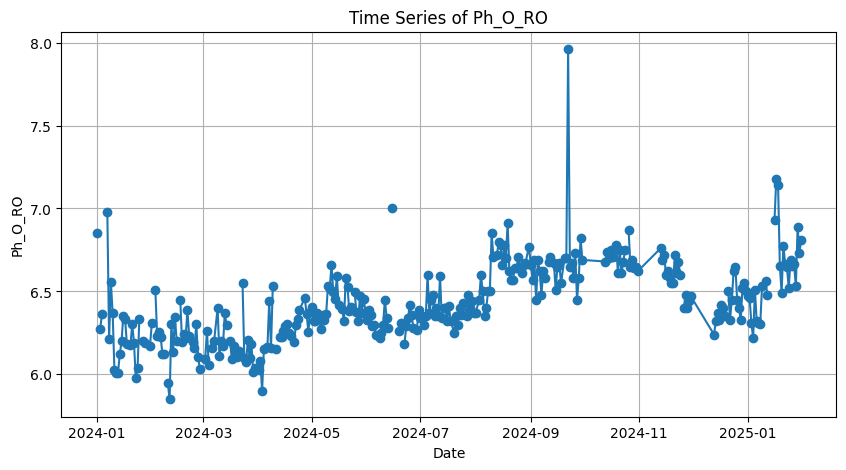

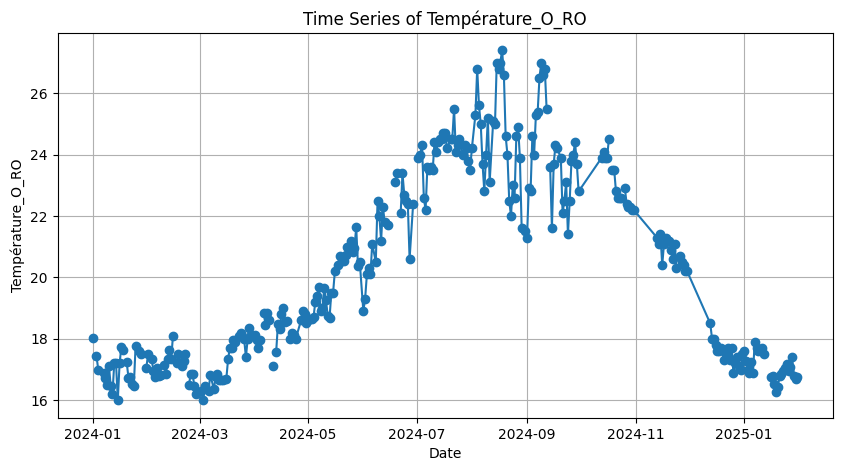

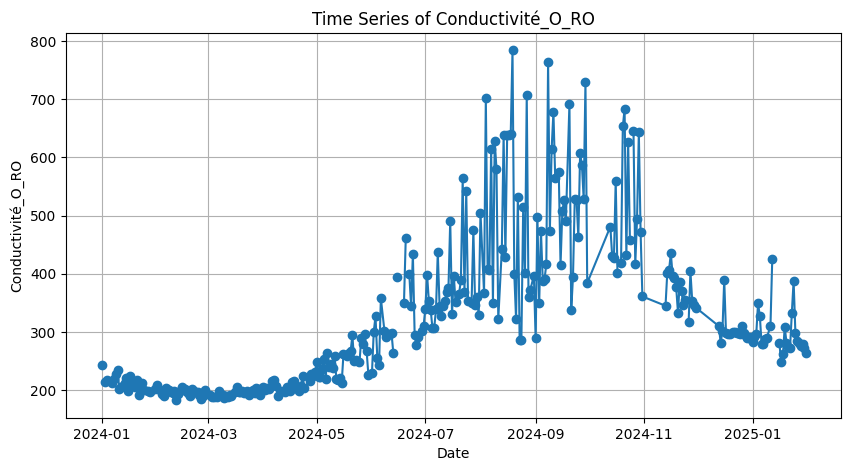

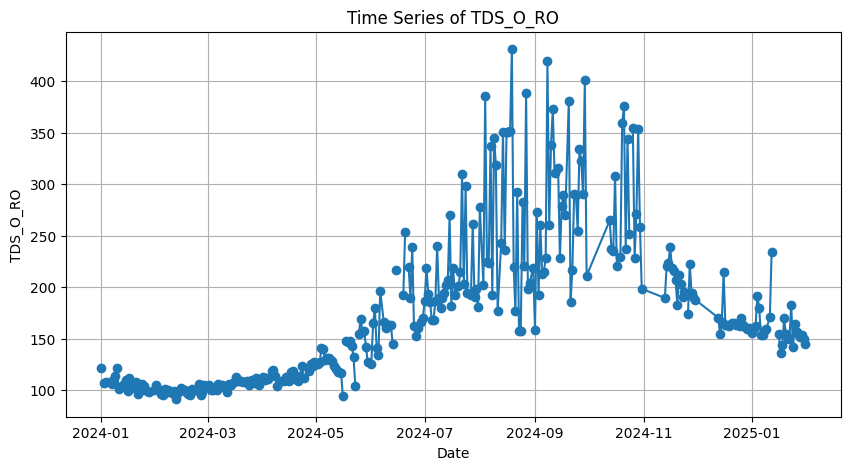

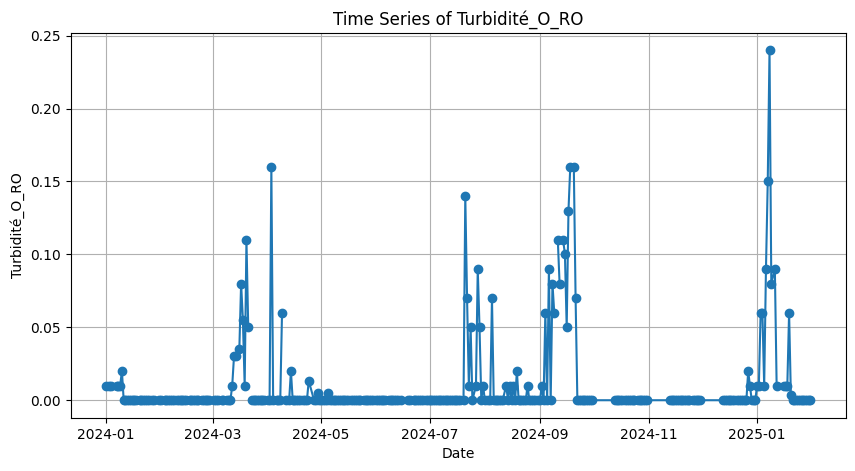

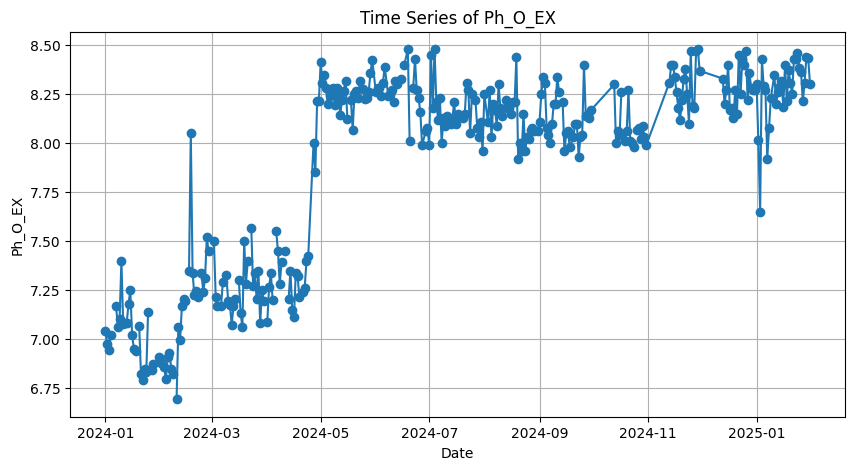

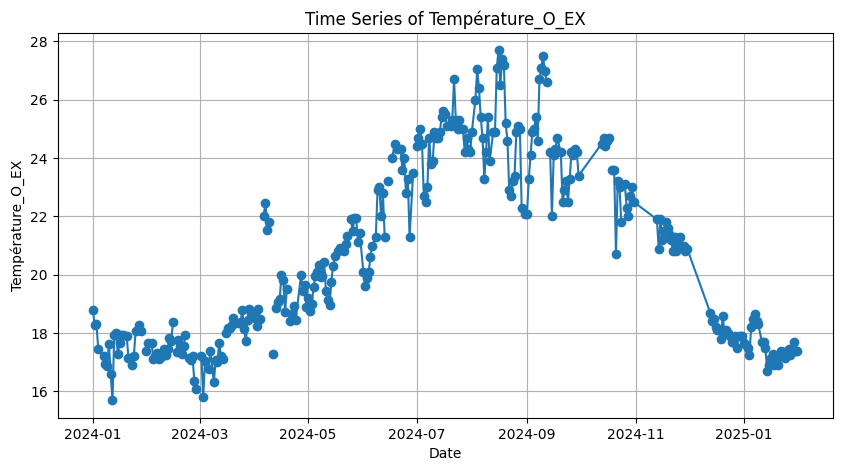

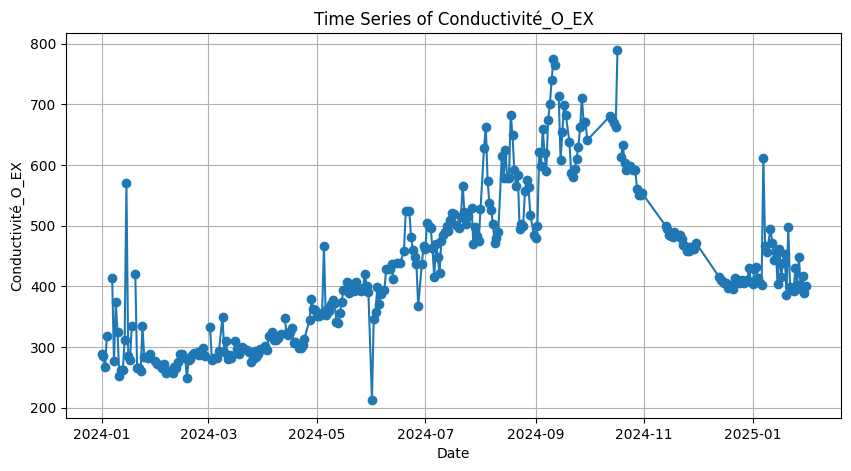

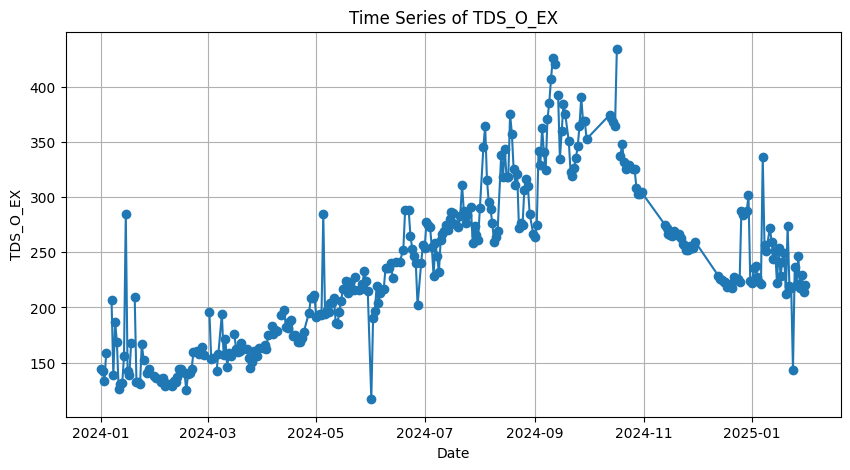

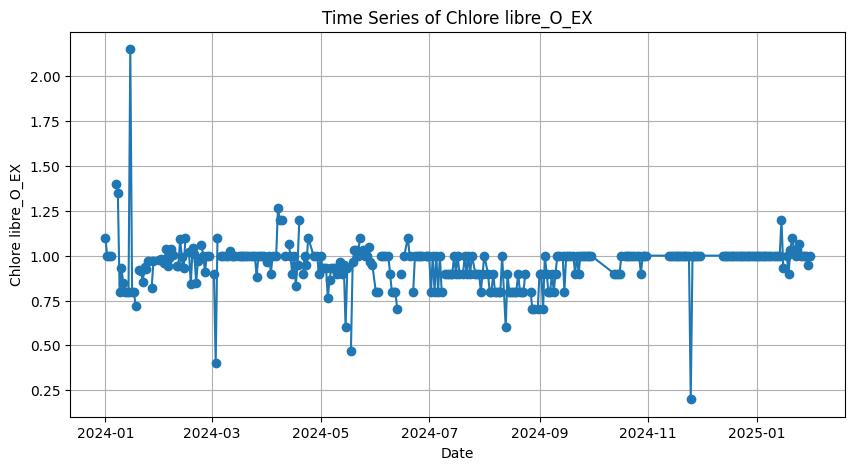

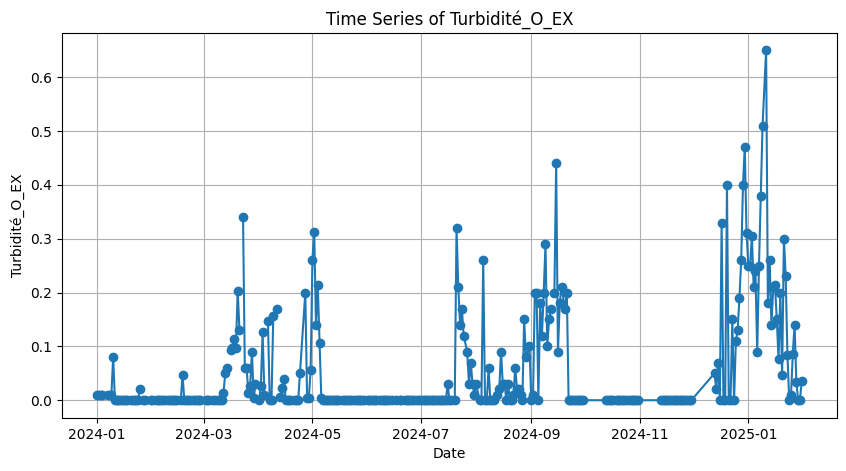

In [1]:
import pandas as pd
import numpy as np

# read the necessary data
rawdata = pd.read_csv('./data/clean/clean_data.csv')
# convert the date column to datetime format
rawdata["DATE"] = pd.to_datetime(rawdata["DATE"], dayfirst=True, errors='coerce')
# turn all column into numeric, except the date  and heure columns
for col in rawdata.columns:
    if col not in ['DATE', 'HEURE']:
        rawdata[col] = pd.to_numeric(rawdata[col], errors='coerce')

# replace Heure values by categories
# 8h00 is the morning, 10h30 or 10h00 is midday, 14h00 or 15h30 is the afternoon.
def categorize_heure(heure):
    if pd.isna(heure):
        return np.nan
    else:
        heure = str(heure).strip()  # Remove any leading/trailing whitespace
        if heure in ['8h00', '8h30']:
            return 'morning'
        elif heure in ['10h00', '10h30']:
            return 'midday'
        elif heure in ['14h00', '15h00', '15h30']:
            return 'afternoon'
        else:
            return 'unknown'
rawdata['HEURE'] = rawdata['HEURE'].apply(categorize_heure)

# avergae the values of the same day
avgdata = rawdata.drop(columns=['HEURE']).groupby('DATE').mean().reset_index()

# loop through all columns and create time series plots to visualize the data
import matplotlib.pyplot as plt
for col in avgdata.columns:
    if col != 'DATE':
        plt.figure(figsize=(10, 5))
        plt.plot(avgdata['DATE'], avgdata[col], marker='o')
        plt.title(f'Time Series of {col}')
        plt.xlabel('Date')
        plt.ylabel(col)
        plt.grid()
        plt.show()

In [2]:
avgdata.describe()

,DATE,pH_BC,Température_BC,Conductivité_BC,TDS_BC,Turbidité_BC,Ph_O_DE_A,Température_O_DE_A,Conductivité_O_DE_A,TDS_O_DE_A,...,Température_O_RO,Conductivité_O_RO,TDS_O_RO,Turbidité_O_RO,Ph_O_EX,Température_O_EX,Conductivité_O_EX,TDS_O_EX,Chlore libre_O_EX,Turbidité_O_EX
count,346,315.000000,314.000000,312.000000,308.000000,312.000000,307.000000,307.000000,33.000000,32.000000,...,310.000000,312.000000,312.000000,311.000000,319.000000,318.000000,319.000000,319.000000,313.000000,319.000000
mean,2024-07-06 00:00:00,8.090325,20.770000,54.319829,36.116025,0.638699,8.064517,20.128534,54.954040,32.988438,...,20.236876,324.217388,176.245019,0.011308,7.900825,20.724565,432.721552,237.221296,0.952838,0.054911
min,2024-01-01 00:00:00,7.900000,15.166667,53.000000,32.500000,0.000000,7.880000,15.233333,53.700000,32.220000,...,16.000000,182.766667,91.383333,0.000000,6.693333,15.700000,212.400000,116.820000,0.200000,0.000000
25%,2024-03-29 06:00:00,8.040000,17.408333,53.800000,33.015000,0.180000,8.010000,17.000000,54.933333,32.960000,...,17.400000,212.750000,112.108333,0.000000,7.371667,17.900000,321.333333,176.991667,0.900000,0.000000
50%,2024-06-29 12:00:00,8.086667,20.425000,54.200000,37.380000,0.357500,8.063333,20.100000,55.033333,33.030000,...,19.450000,293.575000,160.416667,0.000000,8.120000,20.200000,413.000000,228.800000,1.000000,0.000000
75%,2024-09-29 18:00:00,8.130000,24.100000,54.708333,37.800000,0.683333,8.105000,22.900000,55.133333,33.090000,...,22.900000,390.000000,214.500000,0.000000,8.265000,23.475000,500.500000,281.600000,1.000000,0.070000
max,2025-01-31 00:00:00,8.310000,29.000000,56.333333,39.433333,11.133333,8.300000,28.000000,55.466667,33.280000,...,27.400000,784.000000,431.200000,0.240000,8.480000,27.700000,789.000000,433.950000,2.150000,0.650000
std,NaN,0.073668,3.526793,0.781563,2.355257,1.059504,0.071057,3.172274,0.369004,0.204610,...,3.088722,131.803325,74.189046,0.031853,0.498526,3.106521,123.858945,70.632937,0.133723,0.101936


In [2]:
avgdata

,DATE,pH_BC,Température_BC,Conductivité_BC,TDS_BC,Turbidité_BC,Ph_O_DE_A,Température_O_DE_A,Conductivité_O_DE_A,TDS_O_DE_A,...,Température_O_RO,Conductivité_O_RO,TDS_O_RO,Turbidité_O_RO,Ph_O_EX,Température_O_EX,Conductivité_O_EX,TDS_O_EX,Chlore libre_O_EX,Turbidité_O_EX
0,2024-01-01,8.260000,16.833333,55.033333,33.020000,0.403333,8.210000,16.966667,55.033333,33.02,...,18.033333,243.000000,121.500000,0.01,7.040000,18.800000,289.000000,144.500000,1.10,0.010000
1,2024-01-02,8.246667,16.300000,55.000000,33.000000,0.973333,8.200000,16.533333,55.000000,33.00,...,NaN,NaN,NaN,NaN,6.973333,18.266667,285.333333,142.666667,1.00,0.010000
2,2024-01-03,8.226667,17.066667,54.700000,32.820000,0.930000,8.163333,17.500000,54.833333,32.90,...,17.450000,214.800000,107.400000,0.01,6.943333,18.300000,267.666667,133.500000,1.00,0.010000
3,2024-01-04,8.206667,16.933333,54.933333,32.960000,0.326667,8.186667,16.500000,55.066667,33.04,...,17.000000,216.766667,108.383333,0.01,7.020000,17.466667,317.666667,158.833333,1.00,0.010000
4,2024-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,2025-01-27,8.140000,17.933333,55.566667,38.896667,0.370000,8.106667,17.066667,NaN,NaN,...,17.066667,281.666667,154.916667,0.00,8.213333,17.266667,448.333333,246.583333,1.00,0.140000
342,2025-01-28,8.203333,18.000000,55.500000,38.850000,2.596667,8.163333,17.133333,NaN,NaN,...,17.400000,275.333333,151.433333,0.00,8.310000,17.366667,395.000000,217.250000,1.00,0.033333
343,2025-01-29,8.170000,17.200000,NaN,NaN,0.620000,8.120000,16.510000,NaN,NaN,...,16.800000,280.000000,154.000000,0.00,8.440000,17.700000,417.000000,229.350000,1.00,0.000000
344,2025-01-30,8.146667,16.600000,55.533333,38.873333,0.786667,8.136667,16.300000,NaN,NaN,...,16.700000,273.000000,150.150000,0.00,8.436667,17.400000,389.000000,213.950000,0.95,0.000000


In [4]:
avgdata.to_excel('./data/clean/Corso_données_journaliere.xlsx', index=False)

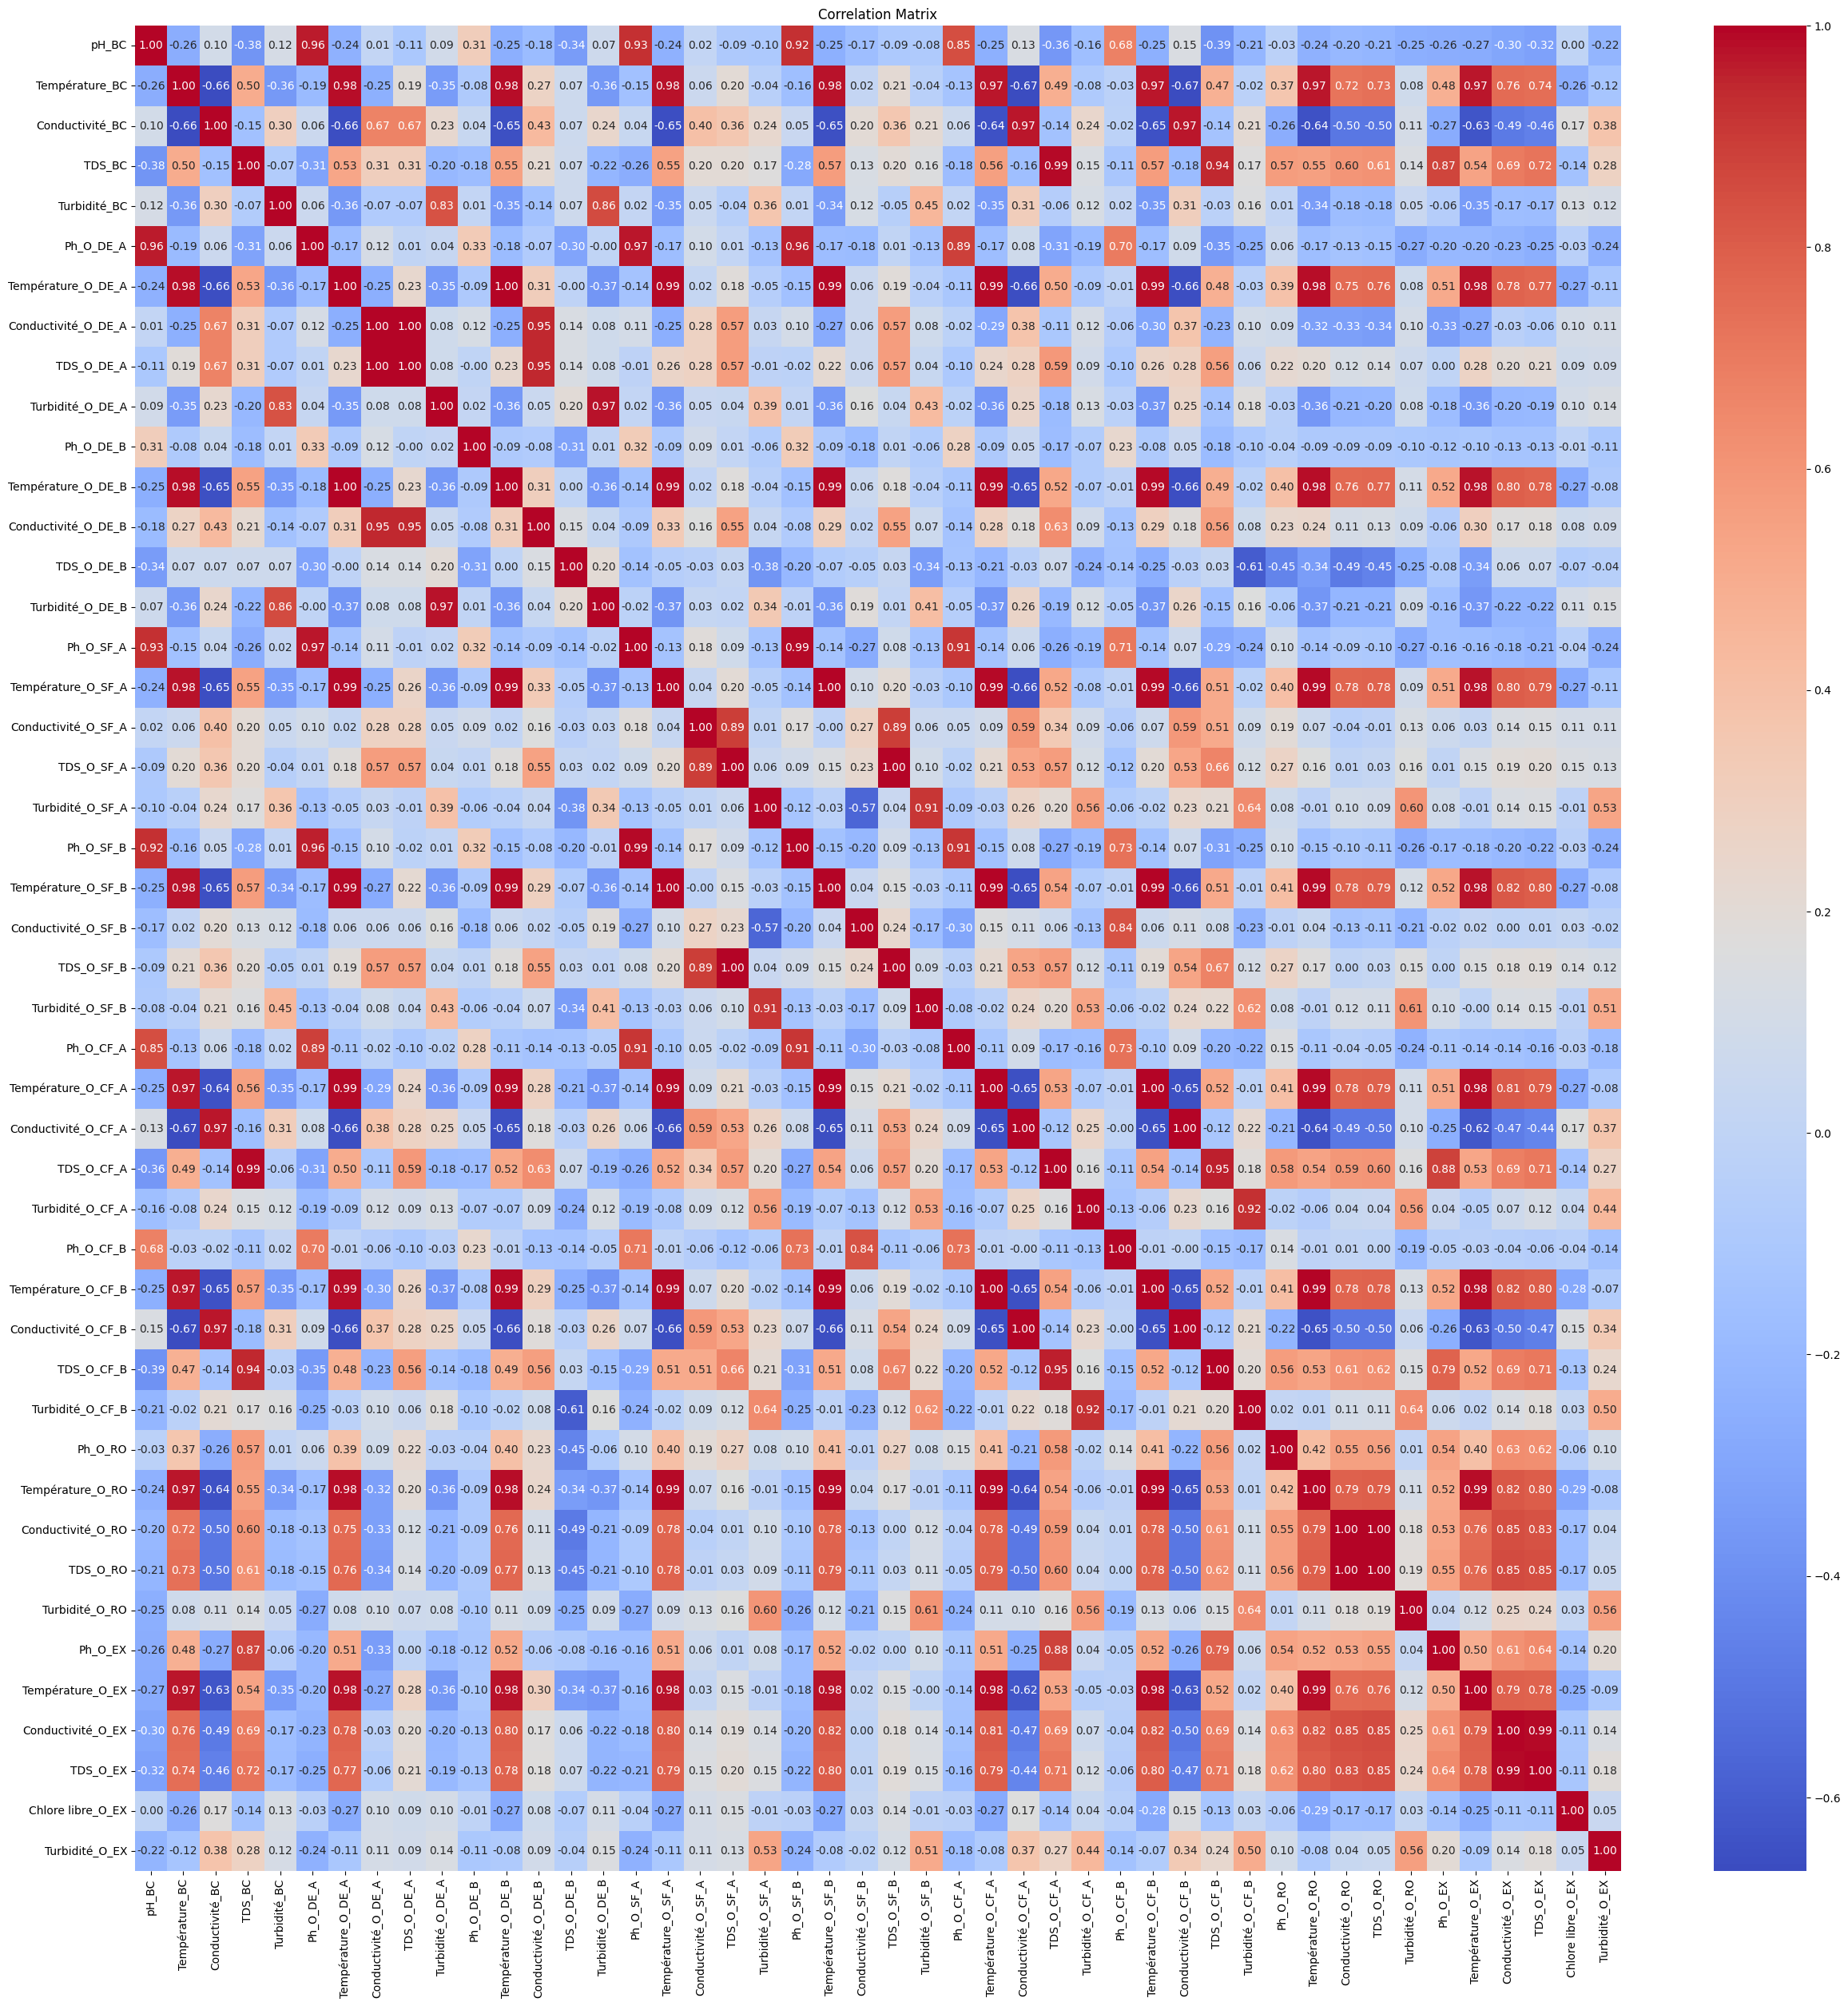

In [ ]:
# correlation matrix
import seaborn as sns
corr_matrix = avgdata.drop(columns=['DATE']).corr()
plt.figure(figsize=(30, 30))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')

plt.show()

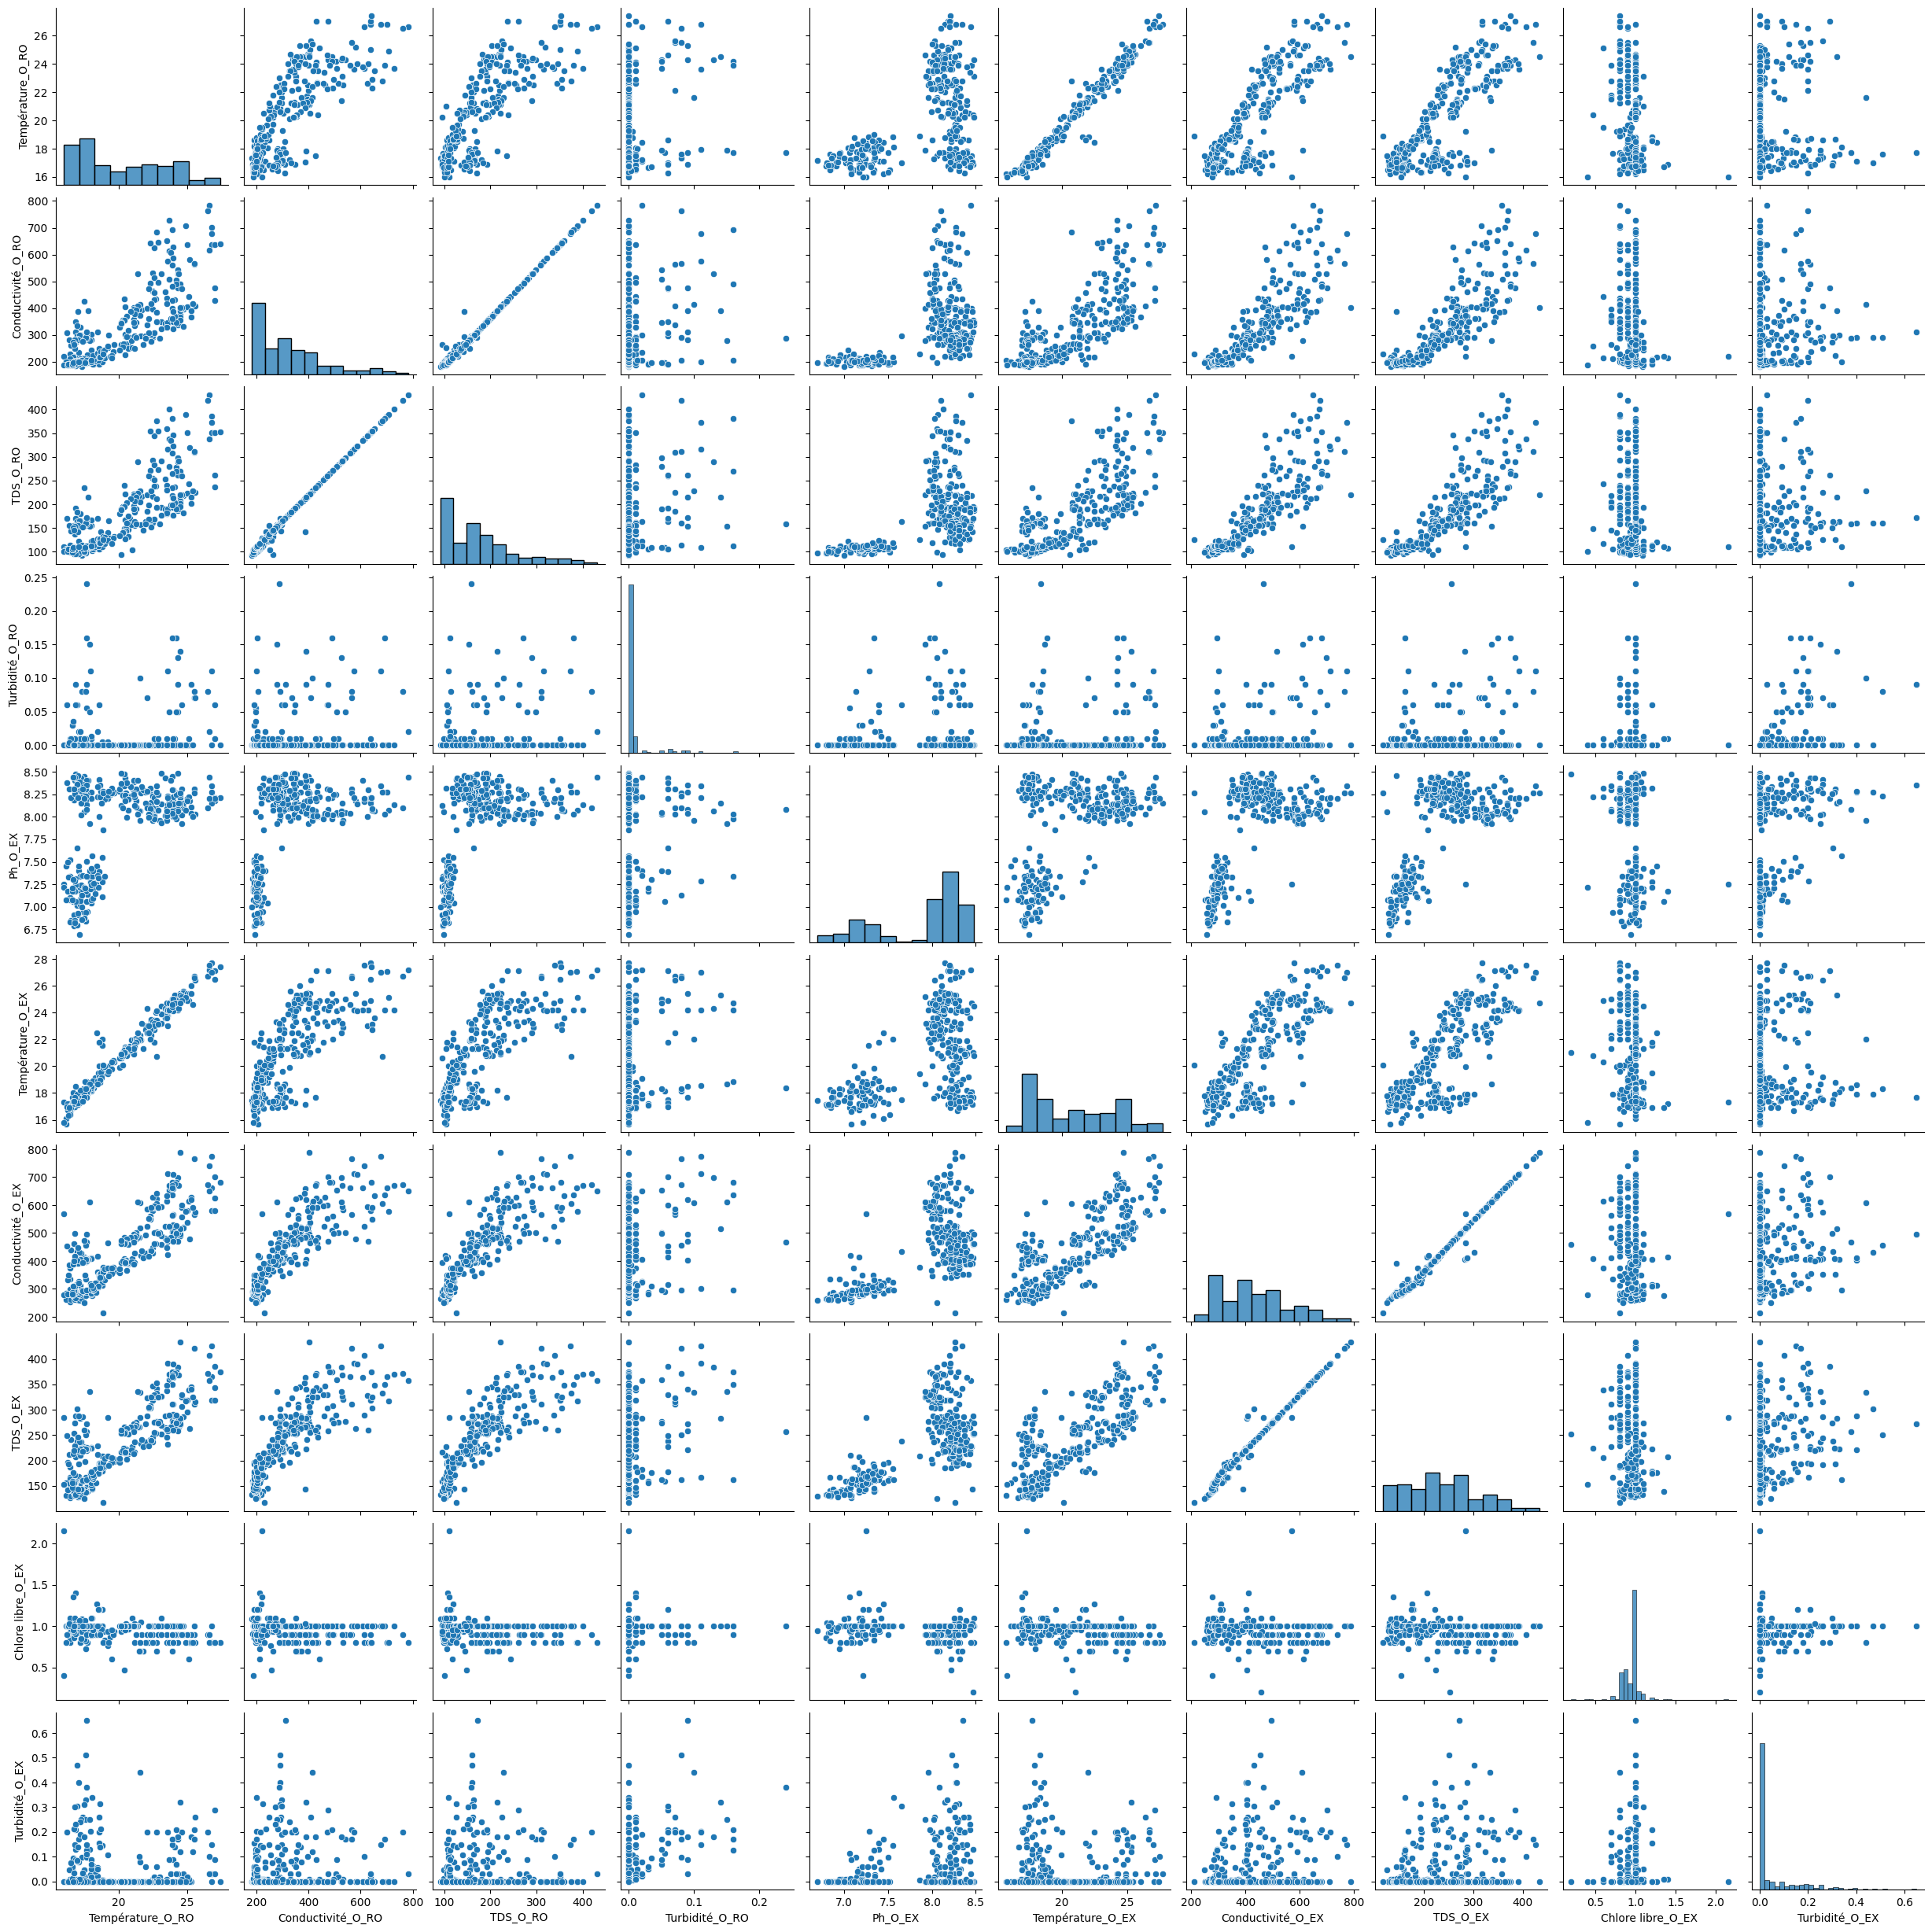

In [3]:
import seaborn as sns

sns.pairplot(avgdata.iloc[:, -10:])